# FrogDQ Experiment Results Analysis

This notebook analyzes the results of hyperparameter optimization experiments to evaluate:
1. **Performance Analysis**: Compare model performance (linear vs MLP, with/without gates, with/without curriculum)
2. **Convergence Speed**: Analyze how quickly models reach target performance levels
3. **Gate Parameter Usage**: Understand which gate configurations are most effective

Analysis is performed separately for:
- **Classification tasks**
- **Regression tasks**

And across different data quality scenarios:
- **Clean**: No data quality issues
- **AR (At Random)**: Random noise in data
- **NAR (Not At Random)**: Systematic noise in data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import optuna
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Configuration and Data Loading

In [2]:
# Configuration
RESULTS_DIR = Path('../results')
DB_PATH = RESULTS_DIR / 'optuna_studies.db'
STORAGE_URL = f'sqlite:///{DB_PATH}'

# Check if results exist
if not DB_PATH.exists():
    # Try symlinked path
    alt_path = Path.home() / 'storage_megaverse' / 'frogdq' / 'results'
    if alt_path.exists():
        RESULTS_DIR = alt_path
        DB_PATH = RESULTS_DIR / 'optuna_studies.db'
        STORAGE_URL = f'sqlite:///{DB_PATH}'
        print(f"Using results from: {RESULTS_DIR}")
    else:
        raise FileNotFoundError(f"Results database not found at {DB_PATH}")
else:
    print(f"Results directory: {RESULTS_DIR}")

print(f"Database: {DB_PATH}")
print(f"Database exists: {DB_PATH.exists()}")

Results directory: ../results
Database: ../results/optuna_studies.db
Database exists: True


In [3]:
# Get dataset metadata
from frogdq.data import get_datasets

datasets_info = get_datasets(data_dir=Path('../data'), poisoned_dir=Path('../data_poisoned'))
print(f"\nAvailable datasets: {len(datasets_info)}")
print("\nDataset summary:")
print(datasets_info[['dataset_name', 'task_type', 'n_samples', 'n_features', 'n_classes']].to_string())

# Create task type mapping
dataset_task_map = dict(zip(datasets_info['dataset_name'], datasets_info['task_type']))


Available datasets: 50

Dataset summary:
                                                                  dataset_name       task_type  n_samples  n_features  n_classes
0                                                                         iris  classification        150           4          3
1                                                                heart_disease      regression        303          13          0
2                                                                 wine_quality      regression       6497          11          0
3                                           breast_cancer_wisconsin_diagnostic  classification        569          30          2
4                                                               bank_marketing  classification      45211          16          2
5                                                                        adult  classification      48842          14          4
6                                                      

In [4]:
# List only classification datasets
classification_datasets = datasets_info[datasets_info['task_type'] == 'classification']['dataset_name'].tolist()
print(f"\nClassification datasets ({len(classification_datasets)}): {classification_datasets}")


Classification datasets (34): ['iris', 'breast_cancer_wisconsin_diagnostic', 'bank_marketing', 'adult', 'wine', 'car_evaluation', 'predict_students_dropout_and_academic_success', 'default_of_credit_card_clients', 'mushroom', 'statlog_german_credit_data', 'estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition', 'spambase', 'online_shoppers_purchasing_intention_dataset', 'magic_gamma_telescope', 'breast_cancer_wisconsin_original', 'breast_cancer', 'dry_bean', 'heart_failure_clinical_records', 'credit_approval', 'chronic_kidney_disease', 'wholesale_customers', 'seoul_bike_sharing_demand', 'rice_cammeo_and_osmancik', 'optical_recognition_of_handwritten_digits', 'glass_identification', 'zoo', 'higher_education_students_performance_evaluation', 'maternal_health_risk', 'early_stage_diabetes_risk_prediction', 'letter_recognition', 'national_poll_on_healthy_aging_npha', 'hepatitis', 'aids_clinical_trials_group_study_175', 'iranian_churn']


In [5]:
# List only regression datasets
regression_datasets = datasets_info[datasets_info['task_type'] == 'regression']['dataset_name'].tolist()
print(f"\nRegression datasets ({len(regression_datasets)}): {regression_datasets}")


Regression datasets (16): ['heart_disease', 'wine_quality', 'automobile', 'abalone', 'bike_sharing', 'auto_mpg', 'forest_fires', 'real_estate_valuation', 'concrete_compressive_strength', 'parkinsons', 'phishing_websites', 'appliances_energy_prediction', 'banknote_authentication', 'productivity_prediction_of_garment_employees', 'combined_cycle_power_plant', 'liver_disorders']


### Load All Studies from Database

In [6]:
from tqdm import tqdm


def parse_study_name(study_name: str) -> Dict[str, str]:
    """
    Parse study name to extract configuration.
    Format: {dataset}_{data_mode}_{model_type}_curr{0/1}_gate{0/1}
    """
    parts = study_name.rsplit('_', 4)
    if len(parts) != 5:
        return None
    
    dataset, data_mode, model_type, curr_part, gate_part = parts
    
    return {
        'dataset': dataset,
        'data_mode': data_mode,
        'model_type': model_type,
        'use_curriculum': curr_part == 'curr1',
        'use_gate': gate_part == 'gate1',
    }

def load_all_studies() -> pd.DataFrame:
    """
    Load all completed studies from the database.
    """
    # Get all study names
    study_summaries = optuna.study.get_all_study_summaries(storage=STORAGE_URL)
    
    print(f"Found {len(study_summaries)} studies in database")
    
    all_results = []
    
    for summary in tqdm(study_summaries):
        study_name = summary.study_name
        config = parse_study_name(study_name)
        
        if config is None:
            print(f"Skipping study with unexpected name format: {study_name}")
            continue
        
        # Load the study
        try:
            study = optuna.load_study(study_name=study_name, storage=STORAGE_URL)
            
            # Get completed trials
            completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
            
            if not completed_trials:
                continue
            
            # Get best trial
            best_trial = max(completed_trials, key=lambda t: t.value if t.value is not None else float('-inf'))
            
            # Extract seed results from best trial
            seed_results = best_trial.user_attrs.get('seed_results', [])
            
            if not seed_results:
                print(f"No seed results found for {study_name}")
                continue
            
            # Get task type
            task_type = dataset_task_map.get(config['dataset'], 'unknown')
            primary_metric = 'f1' if task_type == 'classification' else 'r2'
            
            for seed_result in seed_results:
                if 'error' in seed_result:
                    continue
                
                result_dict = {
                    'study_name': study_name,
                    'dataset': config['dataset'],
                    'task_type': task_type,
                    'data_mode': config['data_mode'],
                    'model_type': config['model_type'],
                    'use_curriculum': config['use_curriculum'],
                    'use_gate': config['use_gate'],
                    'trial_number': best_trial.number,
                    'trial_value': best_trial.value,
                    'seed': seed_result['seed'],
                    # Performance metrics
                    'train_loss': seed_result.get('train_loss'),
                    'val_loss': seed_result.get('val_loss'),
                    'test_loss': seed_result.get('test_loss'),
                    f'train_{primary_metric}': seed_result.get(f'train_{primary_metric}'),
                    f'val_{primary_metric}': seed_result.get(f'val_{primary_metric}'),
                    f'test_{primary_metric}': seed_result.get(f'test_{primary_metric}'),
                    # Convergence metrics
                    'best_epoch': seed_result.get('best_epoch'),
                    'epochs_to_50pct': seed_result.get('epochs_to_50pct'),
                    'epochs_to_75pct': seed_result.get('epochs_to_75pct'),
                    'epochs_to_90pct': seed_result.get('epochs_to_90pct'),
                    'epochs_to_95pct': seed_result.get('epochs_to_95pct'),
                    'epochs_to_99pct': seed_result.get('epochs_to_99pct'),
                    'convergence_stability': seed_result.get('convergence_stability'),
                    # Gate metrics (if applicable)
                    'final_gate_sparsity': seed_result.get('final_gate_sparsity'),
                    'final_gate_std': seed_result.get('final_gate_std'),
                    'gate_change_rate': seed_result.get('gate_change_rate'),
                    # Hyperparameters
                    **best_trial.params,
                }
                
                all_results.append(result_dict)
        
        except Exception as e:
            print(f"Error loading study {study_name}: {e}")
            continue
    
    df = pd.DataFrame(all_results)
    return df

# Load all results
print("Loading results from database...")
results_df = load_all_studies()
print(f"\nLoaded {len(results_df)} results from {results_df['study_name'].nunique()} studies")
print(f"Datasets: {sorted(results_df['dataset'].unique())}")
print(f"\nConfiguration breakdown:")
print(results_df.groupby(['data_mode', 'model_type', 'use_curriculum', 'use_gate']).size())

Loading results from database...
Found 20 studies in database


100%|██████████| 20/20 [00:02<00:00,  7.49it/s]


Loaded 100 results from 20 studies
Datasets: ['breast_cancer_wisconsin_original', 'chronic_kidney_disease']

Configuration breakdown:
data_mode  model_type  use_curriculum  use_gate
ar         linear      False           False       10
           mlp         False           False       10
                                       True        10
                       True            False       10
                                       True        10
clean      linear      False           False       10
           mlp         False           False       10
nar        linear      False           False       10
           mlp         False           False        5
                                       True         5
                       True            False        5
                                       True         5
dtype: int64


### Dataset Completeness Analysis

In [7]:
# Analyze which datasets have complete runs
print("="*80)
print("DATASET COMPLETENESS ANALYSIS")
print("="*80)

# Expected configurations per dataset based on config.yaml
# data_modes: clean, ar, nar (3 modes)
# For clean: only 'linear' and 'mlp' (2 model configs)
# For ar/nar: 'linear', 'mlp', 'mlp+curr', 'mlp+gate', 'mlp+curr+gate' (5 model configs each)
# Total expected: 2 + 5 + 5 = 12 configurations per dataset

expected_configs_per_dataset = {
    'clean': [
        ('clean', 'linear', False, False),
        ('clean', 'mlp', False, False),
    ],
    'ar': [
        ('ar', 'linear', False, False),
        ('ar', 'mlp', False, False),
        ('ar', 'mlp', False, True),
        ('ar', 'mlp', True, False),
        ('ar', 'mlp', True, True),
    ],
    'nar': [
        ('nar', 'linear', False, False),
        ('nar', 'mlp', False, False),
        ('nar', 'mlp', False, True),
        ('nar', 'mlp', True, False),
        ('nar', 'mlp', True, True),
    ]
}

total_expected_configs = sum(len(configs) for configs in expected_configs_per_dataset.values())

# Get unique dataset-configuration combinations from results
dataset_configs = results_df.groupby(['dataset', 'data_mode', 'model_type', 'use_curriculum', 'use_gate']).size().reset_index(name='n_runs')

# Count configurations per dataset
configs_per_dataset = dataset_configs.groupby('dataset').size().reset_index(name='n_configs')

# Identify complete datasets (those with all 12 configurations)
complete_datasets = configs_per_dataset[configs_per_dataset['n_configs'] == total_expected_configs]['dataset'].tolist()
incomplete_datasets = configs_per_dataset[configs_per_dataset['n_configs'] < total_expected_configs]['dataset'].tolist()

# Get all datasets from metadata
all_datasets = set(datasets_info['dataset_name'].tolist())
datasets_with_results = set(results_df['dataset'].unique())
datasets_with_no_results = all_datasets - datasets_with_results

print(f"\nTotal datasets in metadata: {len(all_datasets)}")
print(f"Datasets with at least one result: {len(datasets_with_results)}")
print(f"Datasets with NO results: {len(datasets_with_no_results)}")
if datasets_with_no_results:
    print(f"  Missing datasets: {sorted(datasets_with_no_results)}")

print(f"\nExpected configurations per dataset: {total_expected_configs}")
print(f"Complete datasets (all {total_expected_configs} configs): {len(complete_datasets)}")
print(f"Incomplete datasets: {len(incomplete_datasets)}")

# Show detailed breakdown of incomplete datasets
if incomplete_datasets:
    print(f"\n{'='*80}")
    print("INCOMPLETE DATASETS DETAIL")
    print(f"{'='*80}\n")
    
    for dataset in sorted(incomplete_datasets):
        dataset_data = dataset_configs[dataset_configs['dataset'] == dataset]
        n_configs = len(dataset_data)
        missing_configs = total_expected_configs - n_configs
        
        print(f"\n{dataset}: {n_configs}/{total_expected_configs} configurations ({missing_configs} missing)")
        
        # Show which configurations are present
        present_configs = set()
        for _, row in dataset_data.iterrows():
            config_tuple = (row['data_mode'], row['model_type'], row['use_curriculum'], row['use_gate'])
            present_configs.add(config_tuple)
        
        # Find missing configurations
        all_expected = []
        for mode, configs in expected_configs_per_dataset.items():
            all_expected.extend(configs)
        
        missing = set(all_expected) - present_configs
        
        if missing:
            print("  Missing configurations:")
            for data_mode, model_type, use_curr, use_gate in sorted(missing):
                curr_str = "curr1" if use_curr else "curr0"
                gate_str = "gate1" if use_gate else "gate0"
                print(f"    - {data_mode}_{model_type}_{curr_str}_{gate_str}")

print(f"\n{'='*80}")
print("FILTERING TO COMPLETE DATASETS ONLY")
print(f"{'='*80}\n")

# Filter results to only include complete datasets
results_df_complete = results_df[results_df['dataset'].isin(complete_datasets)].copy()

print(f"Original results: {len(results_df)} rows across {results_df['dataset'].nunique()} datasets")
print(f"Filtered results: {len(results_df_complete)} rows across {results_df_complete['dataset'].nunique()} datasets")
print(f"Removed: {len(results_df) - len(results_df_complete)} rows from {len(incomplete_datasets) + len(datasets_with_no_results)} incomplete/missing datasets")

print(f"\nComplete datasets ({len(complete_datasets)}):")
for i, dataset in enumerate(sorted(complete_datasets), 1):
    task_type = dataset_task_map.get(dataset, 'unknown')
    print(f"  {i:2d}. {dataset:<65s} [{task_type}]")

# Update the main results dataframe to use only complete datasets
results_df = results_df_complete
print(f"\n{'='*80}")
print(f"NOTE: All subsequent analyses will use only the {len(complete_datasets)} complete datasets")
print(f"{'='*80}")

DATASET COMPLETENESS ANALYSIS

Total datasets in metadata: 50
Datasets with at least one result: 2
Datasets with NO results: 48
  Missing datasets: ['abalone', 'adult', 'aids_clinical_trials_group_study_175', 'appliances_energy_prediction', 'auto_mpg', 'automobile', 'bank_marketing', 'banknote_authentication', 'bike_sharing', 'breast_cancer', 'breast_cancer_wisconsin_diagnostic', 'car_evaluation', 'combined_cycle_power_plant', 'concrete_compressive_strength', 'credit_approval', 'default_of_credit_card_clients', 'dry_bean', 'early_stage_diabetes_risk_prediction', 'estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition', 'forest_fires', 'glass_identification', 'heart_disease', 'heart_failure_clinical_records', 'hepatitis', 'higher_education_students_performance_evaluation', 'iranian_churn', 'iris', 'letter_recognition', 'liver_disorders', 'magic_gamma_telescope', 'maternal_health_risk', 'mushroom', 'national_poll_on_healthy_aging_npha', 'online_shoppers_purchasing_int

### Create Model Configuration Labels

In [8]:
import scipy.stats as stats

# ============================================================================
# CONFIGURATION
# ============================================================================

# Set to True to make UCI IDs clickable links
USE_CLICKABLE_UCI_LINKS = True

# ============================================================================
# DATASET METADATA
# ============================================================================

# UCI dataset IDs (extracted from file names in data directory)
uci_ids = {
    'abalone': 1,
    'adult': 2,
    'aids_clinical_trials_group_study_175': 890,
    'appliances_energy_prediction': 374,
    'auto_mpg': 9,
    'automobile': 10,
    'bank_marketing': 222,
    'banknote_authentication': 267,
    'bike_sharing': 275,
    'breast_cancer': 14,
    'breast_cancer_wisconsin_diagnostic': 17,
    'breast_cancer_wisconsin_original': 15,
    'car_evaluation': 19,
    'chronic_kidney_disease': 336,
    'combined_cycle_power_plant': 294,
    'concrete_compressive_strength': 165,
    'credit_approval': 27,
    'default_of_credit_card_clients': 350,
    'dry_bean': 602,
    'early_stage_diabetes_risk_prediction': 529,
    'estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition': 544,
    'forest_fires': 162,
    'glass_identification': 42,
    'heart_disease': 45,
    'heart_failure_clinical_records': 519,
    'hepatitis': 46,
    'higher_education_students_performance_evaluation': 856,
    'iranian_churn': 563,
    'iris': 53,
    'letter_recognition': 59,
    'liver_disorders': 60,
    'magic_gamma_telescope': 159,
    'maternal_health_risk': 863,
    'mushroom': 73,
    'national_poll_on_healthy_aging_npha': 936,
    'online_shoppers_purchasing_intention_dataset': 468,
    'optical_recognition_of_handwritten_digits': 80,
    'parkinsons': 174,
    'phishing_websites': 327,
    'predict_students_dropout_and_academic_success': 697,
    'productivity_prediction_of_garment_employees': 597,
    'real_estate_valuation': 477,
    'rice_cammeo_and_osmancik': 545,
    'seoul_bike_sharing_demand': 560,
    'spambase': 94,
    'statlog_german_credit_data': 144,
    'wholesale_customers': 292,
    'wine': 109,
    'wine_quality': 186,
    'zoo': 111
}

# Create dataset abbreviations dictionary
dataset_abbreviations = {
    'abalone': 'Abal.',
    'adult': 'Adult',
    'aids_clinical_trials_group_study_175': 'AIDS',
    'appliances_energy_prediction': 'AppEn.',
    'auto_mpg': 'AutoMPG',
    'automobile': 'Auto.',
    'bank_marketing': 'BankMkt.',
    'banknote_authentication': 'Banknote',
    'bike_sharing': 'BikeShare',
    'breast_cancer': 'BrCan.',
    'breast_cancer_wisconsin_diagnostic': 'BrCanWD',
    'breast_cancer_wisconsin_original': 'BrCanWO',
    'car_evaluation': 'CarEval.',
    'chronic_kidney_disease': 'CKD',
    'combined_cycle_power_plant': 'CCPP',
    'concrete_compressive_strength': 'Concrete',
    'credit_approval': 'Credit',
    'default_of_credit_card_clients': 'DefCredit',
    'dry_bean': 'DryBean',
    'early_stage_diabetes_risk_prediction': 'Diabetes',
    'estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition': 'Obesity',
    'forest_fires': 'ForestFire',
    'glass_identification': 'Glass',
    'heart_disease': 'HeartDis.',
    'heart_failure_clinical_records': 'HeartFail.',
    'hepatitis': 'Hepatitis',
    'higher_education_students_performance_evaluation': 'HigherEd',
    'iranian_churn': 'IranChurn',
    'iris': 'Iris',
    'letter_recognition': 'LetterRec.',
    'liver_disorders': 'Liver',
    'magic_gamma_telescope': 'MagicGamma',
    'maternal_health_risk': 'MatHealth',
    'mushroom': 'Mushroom',
    'national_poll_on_healthy_aging_npha': 'NPHA',
    'online_shoppers_purchasing_intention_dataset': 'OnlineShop',
    'optical_recognition_of_handwritten_digits': 'OptDigits',
    'parkinsons': 'Parkinson',
    'phishing_websites': 'Phishing',
    'predict_students_dropout_and_academic_success': 'StudentDrop',
    'productivity_prediction_of_garment_employees': 'Garment',
    'real_estate_valuation': 'RealEst.',
    'rice_cammeo_and_osmancik': 'Rice',
    'seoul_bike_sharing_demand': 'SeoulBike',
    'spambase': 'Spambase',
    'statlog_german_credit_data': 'GermanCred.',
    'wholesale_customers': 'Wholesale',
    'wine': 'Wine',
    'wine_quality': 'WineQual.',
    'zoo': 'Zoo'
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def format_dataset_name(dataset, use_links=USE_CLICKABLE_UCI_LINKS):
    """Format dataset name with abbreviated name and UCI ID."""
    abbrev = dataset_abbreviations.get(dataset, dataset)
    uci_id = uci_ids.get(dataset, None)
    
    if uci_id is None:
        return abbrev
    
    if use_links:
        return f"{abbrev} (\\href{{https://archive.ics.uci.edu/dataset/{uci_id}}}{{{uci_id}}})"
    else:
        return f"{abbrev} ({uci_id})"

# ============================================================================
# CLASSIFICATION TABLE
# ============================================================================

# Filter for classification datasets only
classification_df = results_df[results_df['task_type'] == 'classification'].copy()

# Define column order
columns_order = [
    ('clean', 'linear', False, False),
    ('clean', 'mlp', False, False),
    ('ar', 'linear', False, False),
    ('ar', 'mlp', False, False),
    ('ar', 'mlp', True, False),
    ('ar', 'mlp', False, True),
    ('ar', 'mlp', True, True),
    ('nar', 'linear', False, False),
    ('nar', 'mlp', False, False),
    ('nar', 'mlp', True, False),
    ('nar', 'mlp', False, True),
    ('nar', 'mlp', True, True),
]

def get_performance_stats(df, dataset, data_mode, model_type, use_curr, use_gate, metric='test_f1'):
    """Get mean performance for a specific configuration."""
    subset = df[
        (df['dataset'] == dataset) &
        (df['data_mode'] == data_mode) &
        (df['model_type'] == model_type) &
        (df['use_curriculum'] == use_curr) &
        (df['use_gate'] == use_gate)
    ][metric].values
    
    if len(subset) == 0:
        return None
    
    mean = np.mean(subset)
    return mean

# Collect data for all classification datasets
datasets = sorted(classification_df['dataset'].unique())
table_data = {}

for dataset in datasets:
    row_data = []
    for data_mode, model_type, use_curr, use_gate in columns_order:
        mean = get_performance_stats(classification_df, dataset, data_mode, model_type, use_curr, use_gate, 'test_f1')
        row_data.append(mean)
    table_data[dataset] = row_data

# Calculate averages across datasets
avg_performance = []
for col_idx in range(len(columns_order)):
    values = [table_data[ds][col_idx] for ds in datasets if table_data[ds][col_idx] is not None]
    if values:
        avg_performance.append(np.mean(values))
    else:
        avg_performance.append(None)

# Calculate average epochs to 90% and 95%
def get_convergence_stats(df, data_mode, model_type, use_curr, use_gate, metric):
    """Get mean convergence metric across all datasets."""
    subset = df[
        (df['data_mode'] == data_mode) &
        (df['model_type'] == model_type) &
        (df['use_curriculum'] == use_curr) &
        (df['use_gate'] == use_gate)
    ]
    
    if len(subset) == 0:
        return None
    
    # Group by dataset first, then take mean across datasets
    dataset_means = subset.groupby('dataset')[metric].mean()
    return dataset_means.mean()

avg_epochs_90 = []
avg_epochs_95 = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    # Ignore linear models for convergence metrics
    if model_type == 'linear':
        avg_epochs_90.append(None)
        avg_epochs_95.append(None)
    else:
        ep90 = get_convergence_stats(classification_df, data_mode, model_type, use_curr, use_gate, 'epochs_to_90pct')
        ep95 = get_convergence_stats(classification_df, data_mode, model_type, use_curr, use_gate, 'epochs_to_95pct')
        avg_epochs_90.append(ep90)
        avg_epochs_95.append(ep95)

# Generate LaTeX table for classification
latex_lines = []
latex_lines.append(r"\begin{table*}[t]")
latex_lines.append(r"\caption{F1 Score ($\uparrow$) mean over multiple seeds for each classification dataset. All values are scaled by a factor of 100 for readability. For each dataset and summary row, the best model within NAR and NNAR configurations is highlighted in \cellcolor{green!25}$\mathbf{bold + green}$.}")
latex_lines.append(r"\label{tab:classification_results}")
latex_lines.append(r"\begin{center}")
latex_lines.append(r"\begin{small}")
latex_lines.append(r"\begin{sc}")
latex_lines.append(r"\begin{tabularx}{\textwidth}{@{} l | Y Y | Y Y Y Y Y | Y Y Y Y Y @{}}")
latex_lines.append(r"\toprule")

# Header row 1: multicolumn for data modes
latex_lines.append(r"Model; Dataset (ID) & \multicolumn{2}{c|}{Clean} & \multicolumn{5}{c|}{Noise At Random} & \multicolumn{5}{c}{Noise Not At Random} \\")
latex_lines.append(r"\midrule")

# Header rows 2-5: tickboxes for Linear, MLP, Curriculum, Gates
linear_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    linear_marks.append(r"$\checkmark$" if model_type == 'linear' else "")
latex_lines.append("Linear & " + " & ".join(linear_marks) + r" \\")

mlp_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    mlp_marks.append(r"$\checkmark$" if model_type == 'mlp' else "")
latex_lines.append("MLP & " + " & ".join(mlp_marks) + r" \\")

curr_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    curr_marks.append(r"$\checkmark$" if use_curr else "")
latex_lines.append("Curriculum & " + " & ".join(curr_marks) + r" \\")

gate_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    gate_marks.append(r"$\checkmark$" if use_gate else "")
latex_lines.append("Gates & " + " & ".join(gate_marks) + r" \\")

latex_lines.append(r"\midrule")

# Data rows
for dataset in datasets:
    row_data = table_data[dataset]
    
    # Find best in AR (columns 2-6, indices 2-6)
    ar_values = [(i, row_data[i]) for i in range(2, 7) if row_data[i] is not None]
    best_ar_idx = max(ar_values, key=lambda x: x[1])[0] if ar_values else None
    
    # Find best in NAR (columns 7-11, indices 7-11)
    nar_values = [(i, row_data[i]) for i in range(7, 12) if row_data[i] is not None]
    best_nar_idx = max(nar_values, key=lambda x: x[1])[0] if nar_values else None
    
    # Get formatted name with UCI ID
    dataset_display = format_dataset_name(dataset)
    
    row_str = dataset_display
    
    for col_idx, mean in enumerate(row_data):
        if mean is None:
            cell_str = " & ---"
        else:
            mean_scaled = mean * 100
            if col_idx == best_ar_idx or col_idx == best_nar_idx:
                cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{mean_scaled:.2f}}}$"
            else:
                cell_str = f" & ${mean_scaled:.2f}$"
        row_str += cell_str
    
    row_str += r" \\"
    latex_lines.append(row_str)

latex_lines.append(r"\midrule")

# Average performance row
ar_avg_values = [(i, avg_performance[i]) for i in range(2, 7) if avg_performance[i] is not None]
best_ar_avg_idx = max(ar_avg_values, key=lambda x: x[1])[0] if ar_avg_values else None

nar_avg_values = [(i, avg_performance[i]) for i in range(7, 12) if avg_performance[i] is not None]
best_nar_avg_idx = max(nar_avg_values, key=lambda x: x[1])[0] if nar_avg_values else None

row_str = "Average"
for col_idx, mean in enumerate(avg_performance):
    if mean is None:
        cell_str = " & ---"
    else:
        mean_scaled = mean * 100
        if col_idx == best_ar_avg_idx or col_idx == best_nar_avg_idx:
            cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{mean_scaled:.2f}}}$"
        else:
            cell_str = f" & ${mean_scaled:.2f}$"
    row_str += cell_str
row_str += r" \\"
latex_lines.append(row_str)

# Average epochs to 90%
ar_ep90_values = [(i, avg_epochs_90[i]) for i in range(2, 7) if avg_epochs_90[i] is not None]
best_ar_ep90_idx = min(ar_ep90_values, key=lambda x: x[1])[0] if ar_ep90_values else None

nar_ep90_values = [(i, avg_epochs_90[i]) for i in range(7, 12) if avg_epochs_90[i] is not None]
best_nar_ep90_idx = min(nar_ep90_values, key=lambda x: x[1])[0] if nar_ep90_values else None

row_str = "Avg Epochs to 90\\%"
for col_idx, ep in enumerate(avg_epochs_90):
    if ep is None:
        cell_str = " & $-$"
    else:
        if col_idx == best_ar_ep90_idx or col_idx == best_nar_ep90_idx:
            cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{ep:.1f}}}$"
        else:
            cell_str = f" & ${ep:.1f}$"
    row_str += cell_str
row_str += r" \\"
latex_lines.append(row_str)

# Average epochs to 95%
ar_ep95_values = [(i, avg_epochs_95[i]) for i in range(2, 7) if avg_epochs_95[i] is not None]
best_ar_ep95_idx = min(ar_ep95_values, key=lambda x: x[1])[0] if ar_ep95_values else None

nar_ep95_values = [(i, avg_epochs_95[i]) for i in range(7, 12) if avg_epochs_95[i] is not None]
best_nar_ep95_idx = min(nar_ep95_values, key=lambda x: x[1])[0] if nar_ep95_values else None

row_str = "Avg Epochs to 95\\%"
for col_idx, ep in enumerate(avg_epochs_95):
    if ep is None:
        cell_str = " & $-$"
    else:
        if col_idx == best_ar_ep95_idx or col_idx == best_nar_ep95_idx:
            cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{ep:.1f}}}$"
        else:
            cell_str = f" & ${ep:.1f}$"
    row_str += cell_str
row_str += r" \\"
latex_lines.append(row_str)

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabularx}")
latex_lines.append(r"\end{sc}")
latex_lines.append(r"\end{small}")
latex_lines.append(r"\end{center}")
latex_lines.append(r"\end{table*}")

# Print the LaTeX code
latex_table = "\n".join(latex_lines)
print(latex_table)

# Save to file
output_file = RESULTS_DIR / 'classification_table.tex'
with open(output_file, 'w') as f:
    f.write(latex_table)

\begin{table*}[t]
\caption{F1 Score ($\uparrow$) mean over multiple seeds for each classification dataset. All values are scaled by a factor of 100 for readability. For each dataset and summary row, the best model within NAR and NNAR configurations is highlighted in \cellcolor{green!25}$\mathbf{bold + green}$.}
\label{tab:classification_results}
\begin{center}
\begin{small}
\begin{sc}
\begin{tabularx}{\textwidth}{@{} l | Y Y | Y Y Y Y Y | Y Y Y Y Y @{}}
\toprule
Model; Dataset (ID) & \multicolumn{2}{c|}{Clean} & \multicolumn{5}{c|}{Noise At Random} & \multicolumn{5}{c}{Noise Not At Random} \\
\midrule
Linear & $\checkmark$ &  & $\checkmark$ &  &  &  &  & $\checkmark$ &  &  &  &  \\
MLP &  & $\checkmark$ &  & $\checkmark$ & $\checkmark$ & $\checkmark$ & $\checkmark$ &  & $\checkmark$ & $\checkmark$ & $\checkmark$ & $\checkmark$ \\
Curriculum &  &  &  &  & $\checkmark$ &  & $\checkmark$ &  &  & $\checkmark$ &  & $\checkmark$ \\
Gates &  &  &  &  &  & $\checkmark$ & $\checkmark$ &  &  &  

In [9]:
# ============================================================================
# REGRESSION TABLE (R2 - higher is better)
# ============================================================================

# Filter for regression datasets only
regression_df = results_df[results_df['task_type'] == 'regression'].copy()

# Collect data for all regression datasets
datasets_reg = sorted(regression_df['dataset'].unique())
table_data_reg = {}

for dataset in datasets_reg:
    row_data = []
    for data_mode, model_type, use_curr, use_gate in columns_order:
        mean = get_performance_stats(regression_df, dataset, data_mode, model_type, use_curr, use_gate, 'test_r2')
        row_data.append(mean)
    table_data_reg[dataset] = row_data

# Calculate averages across datasets
avg_performance_reg = []
for col_idx in range(len(columns_order)):
    values = [table_data_reg[ds][col_idx] for ds in datasets_reg if table_data_reg[ds][col_idx] is not None]
    if values:
        avg_performance_reg.append(np.mean(values))
    else:
        avg_performance_reg.append(None)

# Calculate average epochs to 90% and 95%
avg_epochs_90_reg = []
avg_epochs_95_reg = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    # Ignore linear models for convergence metrics
    if model_type == 'linear':
        avg_epochs_90_reg.append(None)
        avg_epochs_95_reg.append(None)
    else:
        ep90 = get_convergence_stats(regression_df, data_mode, model_type, use_curr, use_gate, 'epochs_to_90pct')
        ep95 = get_convergence_stats(regression_df, data_mode, model_type, use_curr, use_gate, 'epochs_to_95pct')
        avg_epochs_90_reg.append(ep90)
        avg_epochs_95_reg.append(ep95)

# Generate LaTeX table for regression
latex_lines_reg = []
latex_lines_reg.append(r"\begin{table*}[t]")
latex_lines_reg.append(r"\caption{R$^2$ ($\uparrow$) mean over multiple seeds for each regression dataset. All values are scaled by a factor of 100 for readability. For each dataset and summary row, the best model (highest R$^2$) within NAR and NNAR configurations is highlighted in \cellcolor{green!25}$\mathbf{bold + green}$.}")
latex_lines_reg.append(r"\label{tab:regression_results}")
latex_lines_reg.append(r"\begin{center}")
latex_lines_reg.append(r"\begin{small}")
latex_lines_reg.append(r"\begin{sc}")
latex_lines_reg.append(r"\begin{tabularx}{\textwidth}{@{} l | Y Y | Y Y Y Y Y | Y Y Y Y Y @{}}")
latex_lines_reg.append(r"\toprule")

# Header row 1: multicolumn for data modes
latex_lines_reg.append(r"Model; Dataset (ID) & \multicolumn{2}{c|}{Clean} & \multicolumn{5}{c|}{Noise At Random} & \multicolumn{5}{c}{Noise Not At Random} \\")
latex_lines_reg.append(r"\midrule")

# Header rows 2-5: tickboxes for Linear, MLP, Curriculum, Gates
linear_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    linear_marks.append(r"$\checkmark$" if model_type == 'linear' else "")
latex_lines_reg.append("Linear & " + " & ".join(linear_marks) + r" \\")

mlp_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    mlp_marks.append(r"$\checkmark$" if model_type == 'mlp' else "")
latex_lines_reg.append("MLP & " + " & ".join(mlp_marks) + r" \\")

curr_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    curr_marks.append(r"$\checkmark$" if use_curr else "")
latex_lines_reg.append("Curriculum & " + " & ".join(curr_marks) + r" \\")

gate_marks = []
for data_mode, model_type, use_curr, use_gate in columns_order:
    gate_marks.append(r"$\checkmark$" if use_gate else "")
latex_lines_reg.append("Gates & " + " & ".join(gate_marks) + r" \\")

latex_lines_reg.append(r"\midrule")

# Data rows
for dataset in datasets_reg:
    row_data = table_data_reg[dataset]
    
    # Find best (highest R2) in AR (columns 2-6, indices 2-6)
    ar_values = [(i, row_data[i]) for i in range(2, 7) if row_data[i] is not None]
    best_ar_idx = max(ar_values, key=lambda x: x[1])[0] if ar_values else None
    
    # Find best (highest R2) in NAR (columns 7-11, indices 7-11)
    nar_values = [(i, row_data[i]) for i in range(7, 12) if row_data[i] is not None]
    best_nar_idx = max(nar_values, key=lambda x: x[1])[0] if nar_values else None
    
    # Get formatted name with UCI ID
    dataset_display = format_dataset_name(dataset)
    
    row_str = dataset_display
    
    for col_idx, mean in enumerate(row_data):
        if mean is None:
            cell_str = " & ---"
        else:
            mean_scaled = mean * 100
            if col_idx == best_ar_idx or col_idx == best_nar_idx:
                cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{mean_scaled:.2f}}}$"
            else:
                cell_str = f" & ${mean_scaled:.2f}$"
        row_str += cell_str
    
    row_str += r" \\"
    latex_lines_reg.append(row_str)

latex_lines_reg.append(r"\midrule")

# Average performance row (highest R2 is best)
ar_avg_values_reg = [(i, avg_performance_reg[i]) for i in range(2, 7) if avg_performance_reg[i] is not None]
best_ar_avg_idx_reg = max(ar_avg_values_reg, key=lambda x: x[1])[0] if ar_avg_values_reg else None

nar_avg_values_reg = [(i, avg_performance_reg[i]) for i in range(7, 12) if avg_performance_reg[i] is not None]
best_nar_avg_idx_reg = max(nar_avg_values_reg, key=lambda x: x[1])[0] if nar_avg_values_reg else None

row_str = "Average"
for col_idx, mean in enumerate(avg_performance_reg):
    if mean is None:
        cell_str = " & ---"
    else:
        mean_scaled = mean * 100
        if col_idx == best_ar_avg_idx_reg or col_idx == best_nar_avg_idx_reg:
            cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{mean_scaled:.2f}}}$"
        else:
            cell_str = f" & ${mean_scaled:.2f}$"
    row_str += cell_str
row_str += r" \\"
latex_lines_reg.append(row_str)

# Average epochs to 90% (lower is still better for epochs)
ar_ep90_values_reg = [(i, avg_epochs_90_reg[i]) for i in range(2, 7) if avg_epochs_90_reg[i] is not None]
best_ar_ep90_idx_reg = min(ar_ep90_values_reg, key=lambda x: x[1])[0] if ar_ep90_values_reg else None

nar_ep90_values_reg = [(i, avg_epochs_90_reg[i]) for i in range(7, 12) if avg_epochs_90_reg[i] is not None]
best_nar_ep90_idx_reg = min(nar_ep90_values_reg, key=lambda x: x[1])[0] if nar_ep90_values_reg else None

row_str = "Avg Epochs to 90\\%"
for col_idx, ep in enumerate(avg_epochs_90_reg):
    if ep is None:
        cell_str = " & $-$"
    else:
        if col_idx == best_ar_ep90_idx_reg or col_idx == best_nar_ep90_idx_reg:
            cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{ep:.1f}}}$"
        else:
            cell_str = f" & ${ep:.1f}$"
    row_str += cell_str
row_str += r" \\"
latex_lines_reg.append(row_str)

# Average epochs to 95%
ar_ep95_values_reg = [(i, avg_epochs_95_reg[i]) for i in range(2, 7) if avg_epochs_95_reg[i] is not None]
best_ar_ep95_idx_reg = min(ar_ep95_values_reg, key=lambda x: x[1])[0] if ar_ep95_values_reg else None

nar_ep95_values_reg = [(i, avg_epochs_95_reg[i]) for i in range(7, 12) if avg_epochs_95_reg[i] is not None]
best_nar_ep95_idx_reg = min(nar_ep95_values_reg, key=lambda x: x[1])[0] if nar_ep95_values_reg else None

row_str = "Avg Epochs to 95\\%"
for col_idx, ep in enumerate(avg_epochs_95_reg):
    if ep is None:
        cell_str = " & $-$"
    else:
        if col_idx == best_ar_ep95_idx_reg or col_idx == best_nar_ep95_idx_reg:
            cell_str = f" & \\cellcolor{{green!25}}$\\mathbf{{{ep:.1f}}}$"
        else:
            cell_str = f" & ${ep:.1f}$"
    row_str += cell_str
row_str += r" \\"
latex_lines_reg.append(row_str)

latex_lines_reg.append(r"\bottomrule")
latex_lines_reg.append(r"\end{tabularx}")
latex_lines_reg.append(r"\end{sc}")
latex_lines_reg.append(r"\end{small}")
latex_lines_reg.append(r"\end{center}")
latex_lines_reg.append(r"\end{table*}")

# Print the LaTeX code
latex_table_reg = "\n".join(latex_lines_reg)
print(latex_table_reg)

# Save to file
output_file_reg = RESULTS_DIR / 'regression_table.tex'
with open(output_file_reg, 'w') as f:
    f.write(latex_table_reg)

\begin{table*}[t]
\caption{R$^2$ ($\uparrow$) mean over multiple seeds for each regression dataset. All values are scaled by a factor of 100 for readability. For each dataset and summary row, the best model (highest R$^2$) within NAR and NNAR configurations is highlighted in \cellcolor{green!25}$\mathbf{bold + green}$.}
\label{tab:regression_results}
\begin{center}
\begin{small}
\begin{sc}
\begin{tabularx}{\textwidth}{@{} l | Y Y | Y Y Y Y Y | Y Y Y Y Y @{}}
\toprule
Model; Dataset (ID) & \multicolumn{2}{c|}{Clean} & \multicolumn{5}{c|}{Noise At Random} & \multicolumn{5}{c}{Noise Not At Random} \\
\midrule
Linear & $\checkmark$ &  & $\checkmark$ &  &  &  &  & $\checkmark$ &  &  &  &  \\
MLP &  & $\checkmark$ &  & $\checkmark$ & $\checkmark$ & $\checkmark$ & $\checkmark$ &  & $\checkmark$ & $\checkmark$ & $\checkmark$ & $\checkmark$ \\
Curriculum &  &  &  &  & $\checkmark$ &  & $\checkmark$ &  &  & $\checkmark$ &  & $\checkmark$ \\
Gates &  &  &  &  &  & $\checkmark$ & $\checkmark$ &  &

### LaTeX Performance Table for Classification Datasets

In [10]:
def get_model_label(row):
    """Create human-readable model configuration label."""
    if row['model_type'] == 'linear':
        return 'Linear'
    
    label = 'MLP'
    additions = []
    
    if row['use_curriculum']:
        additions.append('Curr')
    if row['use_gate']:
        additions.append('Gate')
    
    if additions:
        label += ' + ' + ' + '.join(additions)
    
    return label

results_df['model_config'] = results_df.apply(get_model_label, axis=1)
print("\nModel configurations:")
print(results_df['model_config'].value_counts())


Model configurations:
model_config
Linear               15
MLP                  15
MLP + Curr           10
MLP + Gate           10
MLP + Curr + Gate    10
Name: count, dtype: int64


## 2. Performance Analysis

### 2.1 Clean Data Performance

In [11]:
def analyze_performance(df: pd.DataFrame, data_mode: str, task_type: str) -> pd.DataFrame:
    """
    Analyze performance for a specific data mode and task type.
    """
    subset = df[(df['data_mode'] == data_mode) & (df['task_type'] == task_type)].copy()
    
    if len(subset) == 0:
        print(f"No data for {data_mode}/{task_type}")
        return None
    
    metric = 'test_f1' if task_type == 'classification' else 'test_r2'
    
    # Aggregate by dataset and model configuration
    agg_results = subset.groupby(['dataset', 'model_config'])[metric].agg(['mean', 'std', 'count']).reset_index()
    agg_results.columns = ['dataset', 'model_config', 'mean_performance', 'std_performance', 'n_seeds']
    
    return agg_results

# Clean data - Classification
print("="*80)
print("CLEAN DATA - CLASSIFICATION")
print("="*80)
clean_class_perf = analyze_performance(results_df, 'clean', 'classification')
if clean_class_perf is not None:
    print("\nPer-dataset results:")
    pivot_clean_class = clean_class_perf.pivot(index='dataset', columns='model_config', values='mean_performance')
    print(pivot_clean_class.to_string())
    
    print("\n\nAverage across all datasets:")
    avg_clean_class = clean_class_perf.groupby('model_config')['mean_performance'].mean().sort_values(ascending=False)
    print(avg_clean_class.to_string())

# Clean data - Regression
print("\n\n" + "="*80)
print("CLEAN DATA - REGRESSION")
print("="*80)
clean_reg_perf = analyze_performance(results_df, 'clean', 'regression')
if clean_reg_perf is not None:
    print("\nPer-dataset results:")
    pivot_clean_reg = clean_reg_perf.pivot(index='dataset', columns='model_config', values='mean_performance')
    print(pivot_clean_reg.to_string())
    
    print("\n\nAverage across all datasets (higher is better):")
    avg_clean_reg = clean_reg_perf.groupby('model_config')['mean_performance'].mean().sort_values(ascending=False)
    print(avg_clean_reg.to_string())

CLEAN DATA - CLASSIFICATION

Per-dataset results:
model_config                        Linear       MLP
dataset                                             
breast_cancer_wisconsin_original  0.956355  0.944714


Average across all datasets:
model_config
Linear    0.956355
MLP       0.944714


CLEAN DATA - REGRESSION
No data for clean/regression


### 2.2 AR (At Random) Data Performance

In [12]:
# AR data - Classification
print("="*80)
print("AR DATA - CLASSIFICATION")
print("="*80)
ar_class_perf = analyze_performance(results_df, 'ar', 'classification')
if ar_class_perf is not None:
    print("\nPer-dataset results:")
    pivot_ar_class = ar_class_perf.pivot(index='dataset', columns='model_config', values='mean_performance')
    print(pivot_ar_class.to_string())
    
    print("\n\nAverage across all datasets:")
    avg_ar_class = ar_class_perf.groupby('model_config')['mean_performance'].mean().sort_values(ascending=False)
    print(avg_ar_class.to_string())
    
    print("\n\n** Does gating help? **")
    mlp_baseline = avg_ar_class.get('MLP', 0)
    mlp_gate = avg_ar_class.get('MLP + Gate', 0)
    mlp_curr = avg_ar_class.get('MLP + Curr', 0)
    mlp_both = avg_ar_class.get('MLP + Curr + Gate', 0)
    
    if mlp_baseline > 0:
        print(f"MLP baseline: {mlp_baseline:.4f}")
        if mlp_gate > 0:
            improvement = ((mlp_gate - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Gate: {mlp_gate:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_curr > 0:
            improvement = ((mlp_curr - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr: {mlp_curr:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_both > 0:
            improvement = ((mlp_both - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr + Gate: {mlp_both:.4f} ({improvement:+.2f}% vs baseline)")

# AR data - Regression
print("\n\n" + "="*80)
print("AR DATA - REGRESSION")
print("="*80)
ar_reg_perf = analyze_performance(results_df, 'ar', 'regression')
if ar_reg_perf is not None:
    print("\nPer-dataset results:")
    pivot_ar_reg = ar_reg_perf.pivot(index='dataset', columns='model_config', values='mean_performance')
    print(pivot_ar_reg.to_string())
    
    print("\n\nAverage across all datasets (higher is better):")
    avg_ar_reg = ar_reg_perf.groupby('model_config')['mean_performance'].mean().sort_values(ascending=False)
    print(avg_ar_reg.to_string())
    
    print("\n\n** Does gating help? **")
    mlp_baseline = avg_ar_reg.get('MLP', 0)
    mlp_gate = avg_ar_reg.get('MLP + Gate', 0)
    mlp_curr = avg_ar_reg.get('MLP + Curr', 0)
    mlp_both = avg_ar_reg.get('MLP + Curr + Gate', 0)
    
    if mlp_baseline > 0:
        print(f"MLP baseline: {mlp_baseline:.4f}")
        if mlp_gate > 0:
            improvement = ((mlp_gate - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Gate: {mlp_gate:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_curr > 0:
            improvement = ((mlp_curr - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr: {mlp_curr:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_both > 0:
            improvement = ((mlp_both - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr + Gate: {mlp_both:.4f} ({improvement:+.2f}% vs baseline)")

AR DATA - CLASSIFICATION

Per-dataset results:
model_config                        Linear       MLP  MLP + Curr  MLP + Curr + Gate  MLP + Gate
dataset                                                                                        
breast_cancer_wisconsin_original  0.952359  0.954715    0.959054           0.952303    0.959054


Average across all datasets:
model_config
MLP + Curr           0.959054
MLP + Gate           0.959054
MLP                  0.954715
Linear               0.952359
MLP + Curr + Gate    0.952303


** Does gating help? **
MLP baseline: 0.9547
MLP + Gate: 0.9591 (+0.45% vs baseline)
MLP + Curr: 0.9591 (+0.45% vs baseline)
MLP + Curr + Gate: 0.9523 (-0.25% vs baseline)


AR DATA - REGRESSION
No data for ar/regression


### 2.3 NAR (Not At Random) Data Performance

In [13]:
# NAR data - Classification
print("="*80)
print("NAR DATA - CLASSIFICATION")
print("="*80)
nar_class_perf = analyze_performance(results_df, 'nar', 'classification')
if nar_class_perf is not None:
    print("\nPer-dataset results:")
    pivot_nar_class = nar_class_perf.pivot(index='dataset', columns='model_config', values='mean_performance')
    print(pivot_nar_class.to_string())
    
    print("\n\nAverage across all datasets:")
    avg_nar_class = nar_class_perf.groupby('model_config')['mean_performance'].mean().sort_values(ascending=False)
    print(avg_nar_class.to_string())
    
    print("\n\n** Does gating help? **")
    mlp_baseline = avg_nar_class.get('MLP', 0)
    mlp_gate = avg_nar_class.get('MLP + Gate', 0)
    mlp_curr = avg_nar_class.get('MLP + Curr', 0)
    mlp_both = avg_nar_class.get('MLP + Curr + Gate', 0)
    
    if mlp_baseline > 0:
        print(f"MLP baseline: {mlp_baseline:.4f}")
        if mlp_gate > 0:
            improvement = ((mlp_gate - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Gate: {mlp_gate:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_curr > 0:
            improvement = ((mlp_curr - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr: {mlp_curr:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_both > 0:
            improvement = ((mlp_both - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr + Gate: {mlp_both:.4f} ({improvement:+.2f}% vs baseline)")

# NAR data - Regression
print("\n\n" + "="*80)
print("NAR DATA - REGRESSION")
print("="*80)
nar_reg_perf = analyze_performance(results_df, 'nar', 'regression')
if nar_reg_perf is not None:
    print("\nPer-dataset results:")
    pivot_nar_reg = nar_reg_perf.pivot(index='dataset', columns='model_config', values='mean_performance')
    print(pivot_nar_reg.to_string())
    
    print("\n\nAverage across all datasets (higher is better):")
    avg_nar_reg = nar_reg_perf.groupby('model_config')['mean_performance'].mean().sort_values(ascending=False)
    print(avg_nar_reg.to_string())
    
    print("\n\n** Does gating help? **")
    mlp_baseline = avg_nar_reg.get('MLP', 0)
    mlp_gate = avg_nar_reg.get('MLP + Gate', 0)
    mlp_curr = avg_nar_reg.get('MLP + Curr', 0)
    mlp_both = avg_nar_reg.get('MLP + Curr + Gate', 0)
    
    if mlp_baseline > 0:
        print(f"MLP baseline: {mlp_baseline:.4f}")
        if mlp_gate > 0:
            improvement = ((mlp_gate - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Gate: {mlp_gate:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_curr > 0:
            improvement = ((mlp_curr - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr: {mlp_curr:.4f} ({improvement:+.2f}% vs baseline)")
        if mlp_both > 0:
            improvement = ((mlp_both - mlp_baseline) / mlp_baseline) * 100
            print(f"MLP + Curr + Gate: {mlp_both:.4f} ({improvement:+.2f}% vs baseline)")

NAR DATA - CLASSIFICATION

Per-dataset results:
model_config                        Linear      MLP  MLP + Curr  MLP + Curr + Gate  MLP + Gate
dataset                                                                                       
breast_cancer_wisconsin_original  0.952737  0.95661    0.954371           0.956559     0.95661


Average across all datasets:
model_config
MLP                  0.956610
MLP + Gate           0.956610
MLP + Curr + Gate    0.956559
MLP + Curr           0.954371
Linear               0.952737


** Does gating help? **
MLP baseline: 0.9566
MLP + Gate: 0.9566 (+0.00% vs baseline)
MLP + Curr: 0.9544 (-0.23% vs baseline)
MLP + Curr + Gate: 0.9566 (-0.01% vs baseline)


NAR DATA - REGRESSION
No data for nar/regression


### 2.4 Performance Visualization

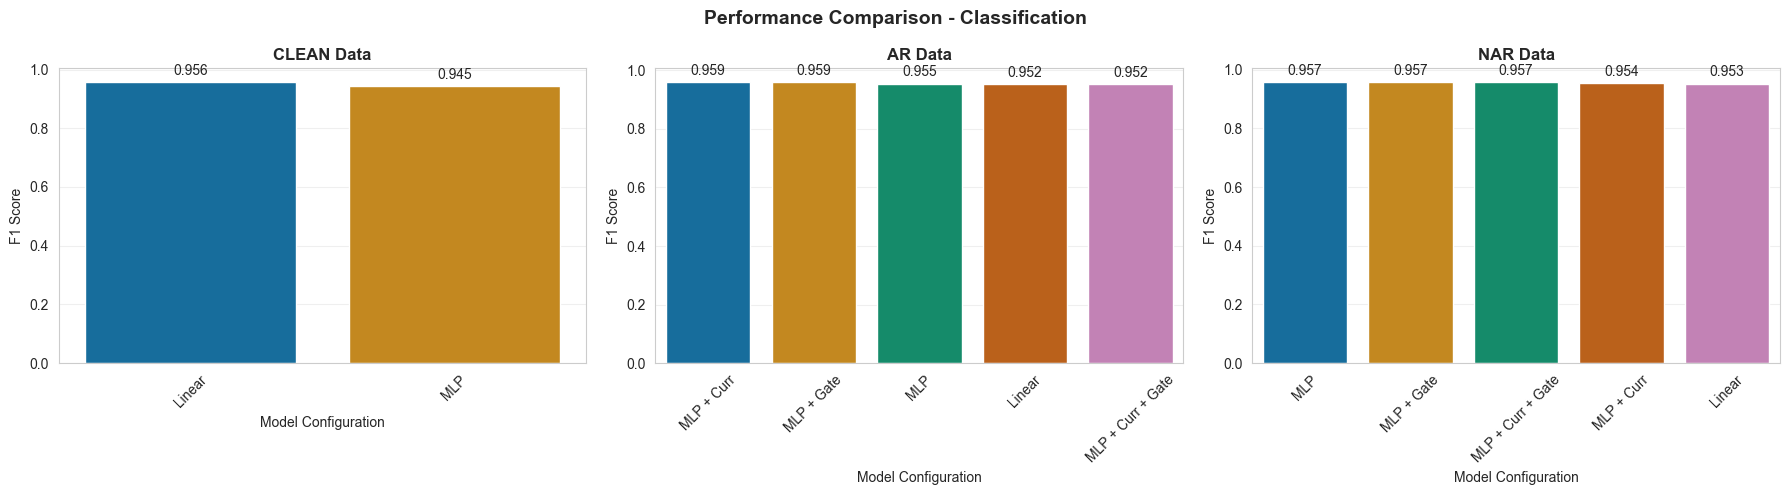

No data for regression


In [14]:
def plot_performance_comparison(df: pd.DataFrame, task_type: str):
    """
    Create bar plots comparing performance across configurations.
    """
    subset = df[df['task_type'] == task_type].copy()
    
    if len(subset) == 0:
        print(f"No data for {task_type}")
        return
    
    metric = 'test_f1' if task_type == 'classification' else 'test_r2'
    metric_name = 'F1 Score' if task_type == 'classification' else 'R$^2$'
    
    # Compute averages across datasets
    avg_perf = subset.groupby(['data_mode', 'model_config'])[metric].mean().reset_index()
    
    # Create plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Performance Comparison - {task_type.capitalize()}', fontsize=14, fontweight='bold')
    
    for idx, mode in enumerate(['clean', 'ar', 'nar']):
        ax = axes[idx]
        mode_data = avg_perf[avg_perf['data_mode'] == mode].sort_values(metric, ascending=False)
        
        if len(mode_data) > 0:
            sns.barplot(data=mode_data, x='model_config', y=metric, ax=ax, palette='colorblind')
            ax.set_title(f'{mode.upper()} Data', fontweight='bold')
            ax.set_xlabel('Model Configuration')
            ax.set_ylabel(metric_name)
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
            
            # Add value labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f', padding=3)
        else:
            ax.text(0.5, 0.5, f'No data for {mode}', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()

# Plot for classification
plot_performance_comparison(results_df, 'classification')

# Plot for regression
plot_performance_comparison(results_df, 'regression')

## 3. Convergence Speed Analysis

### 3.1 Clean Data Convergence

In [15]:
def analyze_convergence(df: pd.DataFrame, data_mode: str, task_type: str) -> pd.DataFrame:
    """
    Analyze convergence speed for a specific data mode and task type.
    """
    subset = df[(df['data_mode'] == data_mode) & (df['task_type'] == task_type)].copy()
    
    if len(subset) == 0:
        print(f"No data for {data_mode}/{task_type}")
        return None
    
    # Aggregate convergence metrics
    convergence_cols = ['best_epoch', 'epochs_to_50pct', 'epochs_to_75pct', 
                       'epochs_to_90pct', 'epochs_to_95pct', 'epochs_to_99pct']
    
    agg_results = subset.groupby(['dataset', 'model_config'])[convergence_cols].mean().reset_index()
    
    return agg_results

# Clean data - Classification
print("="*80)
print("CONVERGENCE SPEED - CLEAN DATA - CLASSIFICATION")
print("="*80)
clean_class_conv = analyze_convergence(results_df, 'clean', 'classification')
if clean_class_conv is not None:
    print("\nAverage epochs to reach performance thresholds:")
    avg_clean_class_conv = clean_class_conv.groupby('model_config')[['epochs_to_90pct', 'epochs_to_95pct']].mean()
    print(avg_clean_class_conv.to_string())

# Clean data - Regression
print("\n\n" + "="*80)
print("CONVERGENCE SPEED - CLEAN DATA - REGRESSION")
print("="*80)
clean_reg_conv = analyze_convergence(results_df, 'clean', 'regression')
if clean_reg_conv is not None:
    print("\nAverage epochs to reach performance thresholds:")
    avg_clean_reg_conv = clean_reg_conv.groupby('model_config')[['epochs_to_90pct', 'epochs_to_95pct']].mean()
    print(avg_clean_reg_conv.to_string())

CONVERGENCE SPEED - CLEAN DATA - CLASSIFICATION

Average epochs to reach performance thresholds:
              epochs_to_90pct  epochs_to_95pct
model_config                                  
Linear                    1.2              2.0
MLP                       1.2              1.6


CONVERGENCE SPEED - CLEAN DATA - REGRESSION
No data for clean/regression


### 3.2 AR Data Convergence

In [16]:
# AR data - Classification
print("="*80)
print("CONVERGENCE SPEED - AR DATA - CLASSIFICATION")
print("="*80)
ar_class_conv = analyze_convergence(results_df, 'ar', 'classification')
if ar_class_conv is not None:
    print("\nAverage epochs to reach performance thresholds:")
    avg_ar_class_conv = ar_class_conv.groupby('model_config')[['epochs_to_90pct', 'epochs_to_95pct']].mean()
    print(avg_ar_class_conv.to_string())
    
    print("\n\n** Does gating improve convergence speed? **")
    mlp_baseline = avg_ar_class_conv.loc['MLP', 'epochs_to_90pct'] if 'MLP' in avg_ar_class_conv.index else None
    mlp_gate = avg_ar_class_conv.loc['MLP + Gate', 'epochs_to_90pct'] if 'MLP + Gate' in avg_ar_class_conv.index else None
    
    if mlp_baseline is not None:
        print(f"MLP baseline - epochs to 90%: {mlp_baseline:.1f}")
        if mlp_gate is not None:
            speedup = ((mlp_baseline - mlp_gate) / mlp_baseline) * 100
            print(f"MLP + Gate - epochs to 90%: {mlp_gate:.1f} ({speedup:+.1f}% faster)")

# AR data - Regression
print("\n\n" + "="*80)
print("CONVERGENCE SPEED - AR DATA - REGRESSION")
print("="*80)
ar_reg_conv = analyze_convergence(results_df, 'ar', 'regression')
if ar_reg_conv is not None:
    print("\nAverage epochs to reach performance thresholds:")
    avg_ar_reg_conv = ar_reg_conv.groupby('model_config')[['epochs_to_90pct', 'epochs_to_95pct']].mean()
    print(avg_ar_reg_conv.to_string())
    
    print("\n\n** Does gating improve convergence speed? **")
    mlp_baseline = avg_ar_reg_conv.loc['MLP', 'epochs_to_90pct'] if 'MLP' in avg_ar_reg_conv.index else None
    mlp_gate = avg_ar_reg_conv.loc['MLP + Gate', 'epochs_to_90pct'] if 'MLP + Gate' in avg_ar_reg_conv.index else None
    
    if mlp_baseline is not None:
        print(f"MLP baseline - epochs to 90%: {mlp_baseline:.1f}")
        if mlp_gate is not None:
            speedup = ((mlp_baseline - mlp_gate) / mlp_baseline) * 100
            print(f"MLP + Gate - epochs to 90%: {mlp_gate:.1f} ({speedup:+.1f}% faster)")

CONVERGENCE SPEED - AR DATA - CLASSIFICATION

Average epochs to reach performance thresholds:
                   epochs_to_90pct  epochs_to_95pct
model_config                                       
Linear                         1.0              2.0
MLP                            0.8              1.6
MLP + Curr                     1.2              2.4
MLP + Curr + Gate              0.8              1.6
MLP + Gate                     1.0              1.6


** Does gating improve convergence speed? **
MLP baseline - epochs to 90%: 0.8
MLP + Gate - epochs to 90%: 1.0 (-25.0% faster)


CONVERGENCE SPEED - AR DATA - REGRESSION
No data for ar/regression


### 3.3 NAR Data Convergence

In [17]:
# NAR data - Classification
print("="*80)
print("CONVERGENCE SPEED - NAR DATA - CLASSIFICATION")
print("="*80)
nar_class_conv = analyze_convergence(results_df, 'nar', 'classification')
if nar_class_conv is not None:
    print("\nAverage epochs to reach performance thresholds:")
    avg_nar_class_conv = nar_class_conv.groupby('model_config')[['epochs_to_90pct', 'epochs_to_95pct']].mean()
    print(avg_nar_class_conv.to_string())
    
    print("\n\n** Does gating improve convergence speed? **")
    mlp_baseline = avg_nar_class_conv.loc['MLP', 'epochs_to_90pct'] if 'MLP' in avg_nar_class_conv.index else None
    mlp_gate = avg_nar_class_conv.loc['MLP + Gate', 'epochs_to_90pct'] if 'MLP + Gate' in avg_nar_class_conv.index else None
    
    if mlp_baseline is not None:
        print(f"MLP baseline - epochs to 90%: {mlp_baseline:.1f}")
        if mlp_gate is not None:
            speedup = ((mlp_baseline - mlp_gate) / mlp_baseline) * 100
            print(f"MLP + Gate - epochs to 90%: {mlp_gate:.1f} ({speedup:+.1f}% faster)")

# NAR data - Regression
print("\n\n" + "="*80)
print("CONVERGENCE SPEED - NAR DATA - REGRESSION")
print("="*80)
nar_reg_conv = analyze_convergence(results_df, 'nar', 'regression')
if nar_reg_conv is not None:
    print("\nAverage epochs to reach performance thresholds:")
    avg_nar_reg_conv = nar_reg_conv.groupby('model_config')[['epochs_to_90pct', 'epochs_to_95pct']].mean()
    print(avg_nar_reg_conv.to_string())
    
    print("\n\n** Does gating improve convergence speed? **")
    mlp_baseline = avg_nar_reg_conv.loc['MLP', 'epochs_to_90pct'] if 'MLP' in avg_nar_reg_conv.index else None
    mlp_gate = avg_nar_reg_conv.loc['MLP + Gate', 'epochs_to_90pct'] if 'MLP + Gate' in avg_nar_reg_conv.index else None
    
    if mlp_baseline is not None:
        print(f"MLP baseline - epochs to 90%: {mlp_baseline:.1f}")
        if mlp_gate is not None:
            speedup = ((mlp_baseline - mlp_gate) / mlp_baseline) * 100
            print(f"MLP + Gate - epochs to 90%: {mlp_gate:.1f} ({speedup:+.1f}% faster)")

CONVERGENCE SPEED - NAR DATA - CLASSIFICATION

Average epochs to reach performance thresholds:
                   epochs_to_90pct  epochs_to_95pct
model_config                                       
Linear                         0.6              1.4
MLP                            3.8              5.2
MLP + Curr                     4.6              5.8
MLP + Curr + Gate              3.6              5.0
MLP + Gate                     3.2              4.2


** Does gating improve convergence speed? **
MLP baseline - epochs to 90%: 3.8
MLP + Gate - epochs to 90%: 3.2 (+15.8% faster)


CONVERGENCE SPEED - NAR DATA - REGRESSION
No data for nar/regression


### 3.4 Convergence Visualization

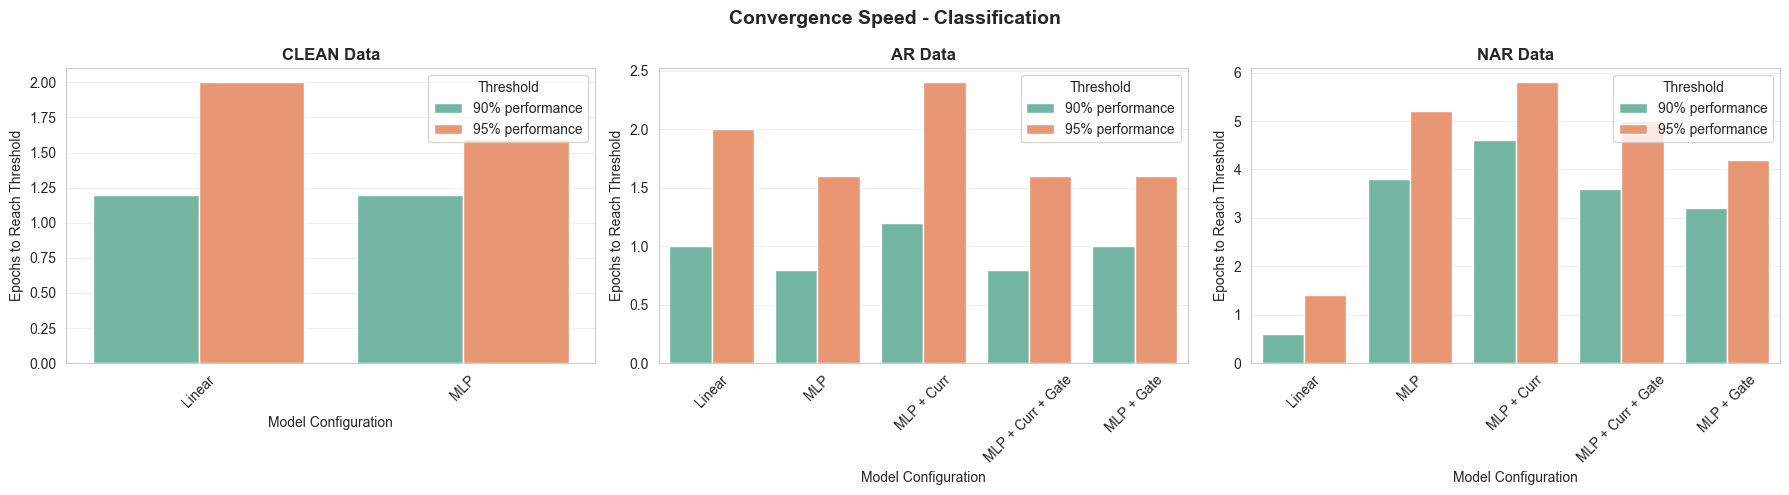

No data for regression


In [18]:
def plot_convergence_comparison(df: pd.DataFrame, task_type: str):
    """
    Create bar plots comparing convergence speed across configurations.
    """
    subset = df[df['task_type'] == task_type].copy()
    
    if len(subset) == 0:
        print(f"No data for {task_type}")
        return
    
    # Compute averages
    avg_conv = subset.groupby(['data_mode', 'model_config'])[['epochs_to_90pct', 'epochs_to_95pct']].mean().reset_index()
    
    # Create plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Convergence Speed - {task_type.capitalize()}', fontsize=14, fontweight='bold')
    
    for idx, mode in enumerate(['clean', 'ar', 'nar']):
        ax = axes[idx]
        mode_data = avg_conv[avg_conv['data_mode'] == mode].copy()
        
        if len(mode_data) > 0:
            # Melt for grouped bar plot
            mode_data_melt = mode_data.melt(id_vars=['model_config'], 
                                            value_vars=['epochs_to_90pct', 'epochs_to_95pct'],
                                            var_name='threshold', value_name='epochs')
            mode_data_melt['threshold'] = mode_data_melt['threshold'].map({
                'epochs_to_90pct': '90% performance',
                'epochs_to_95pct': '95% performance'
            })
            
            sns.barplot(data=mode_data_melt, x='model_config', y='epochs', hue='threshold', ax=ax, palette='Set2')
            ax.set_title(f'{mode.upper()} Data', fontweight='bold')
            ax.set_xlabel('Model Configuration')
            ax.set_ylabel('Epochs to Reach Threshold')
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
            ax.legend(title='Threshold', loc='upper right')
        else:
            ax.text(0.5, 0.5, f'No data for {mode}', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()

# Plot for classification
plot_convergence_comparison(results_df, 'classification')

# Plot for regression
plot_convergence_comparison(results_df, 'regression')

## 4. Gate Parameter Analysis

### 4.1 Most Used Gate Parameters

In [19]:
# Filter for experiments with gates
gate_experiments = results_df[results_df['use_gate'] == True].copy()

if len(gate_experiments) > 0:
    print("="*80)
    print("GATE PARAMETER USAGE ANALYSIS")
    print("="*80)
    
    # Analyze gate hyperparameters
    gate_params = ['gate_init', 'gate_loss_weight', 'gate_anchor_interval', 
                   'gate_quality_weighting', 'gate_loss_scheduler']
    
    print("\n### Categorical Parameters ###\n")
    for param in ['gate_init', 'gate_quality_weighting', 'gate_loss_scheduler']:
        if param in gate_experiments.columns:
            print(f"\n{param}:")
            counts = gate_experiments[param].value_counts()
            percentages = gate_experiments[param].value_counts(normalize=True) * 100
            summary = pd.DataFrame({'count': counts, 'percentage': percentages})
            print(summary.to_string())
    
    print("\n\n### Numerical Parameters ###\n")
    for param in ['gate_loss_weight', 'gate_anchor_interval']:
        if param in gate_experiments.columns:
            print(f"\n{param}:")
            stats = gate_experiments[param].describe()
            print(stats.to_string())
    
    # Gate sparsity analysis
    print("\n\n### Gate Weight Statistics ###\n")
    if 'final_gate_sparsity' in gate_experiments.columns:
        print("\nFinal gate sparsity (mean gate weight):")
        sparsity_stats = gate_experiments.groupby(['data_mode', 'task_type'])['final_gate_sparsity'].describe()
        print(sparsity_stats.to_string())
        
        print("\nInterpretation: Higher values mean gates are more open (less filtering).")
        print("Values close to 0 mean gates are heavily filtering features.")
else:
    print("No gate experiments found in the results.")

GATE PARAMETER USAGE ANALYSIS

### Categorical Parameters ###


gate_init:
           count  percentage
gate_init                   
ones          20       100.0

gate_quality_weighting:
                        count  percentage
gate_quality_weighting                   
exp                        10        50.0
linear                      5        25.0
quadratic                   5        25.0

gate_loss_scheduler:
                     count  percentage
gate_loss_scheduler                   
cosine                  10        50.0
decay                   10        50.0


### Numerical Parameters ###


gate_loss_weight:
count    20.000000
mean      0.009418
std       0.009536
min       0.000195
25%       0.001191
50%       0.007210
75%       0.015437
max       0.023059

gate_anchor_interval:
count    20.000000
mean     11.250000
std       0.850696
min      10.000000
25%      10.750000
50%      11.500000
75%      12.000000
max      12.000000


### Gate Weight Statistics ###


Final gate s

### 4.2 Gate Parameter Visualization

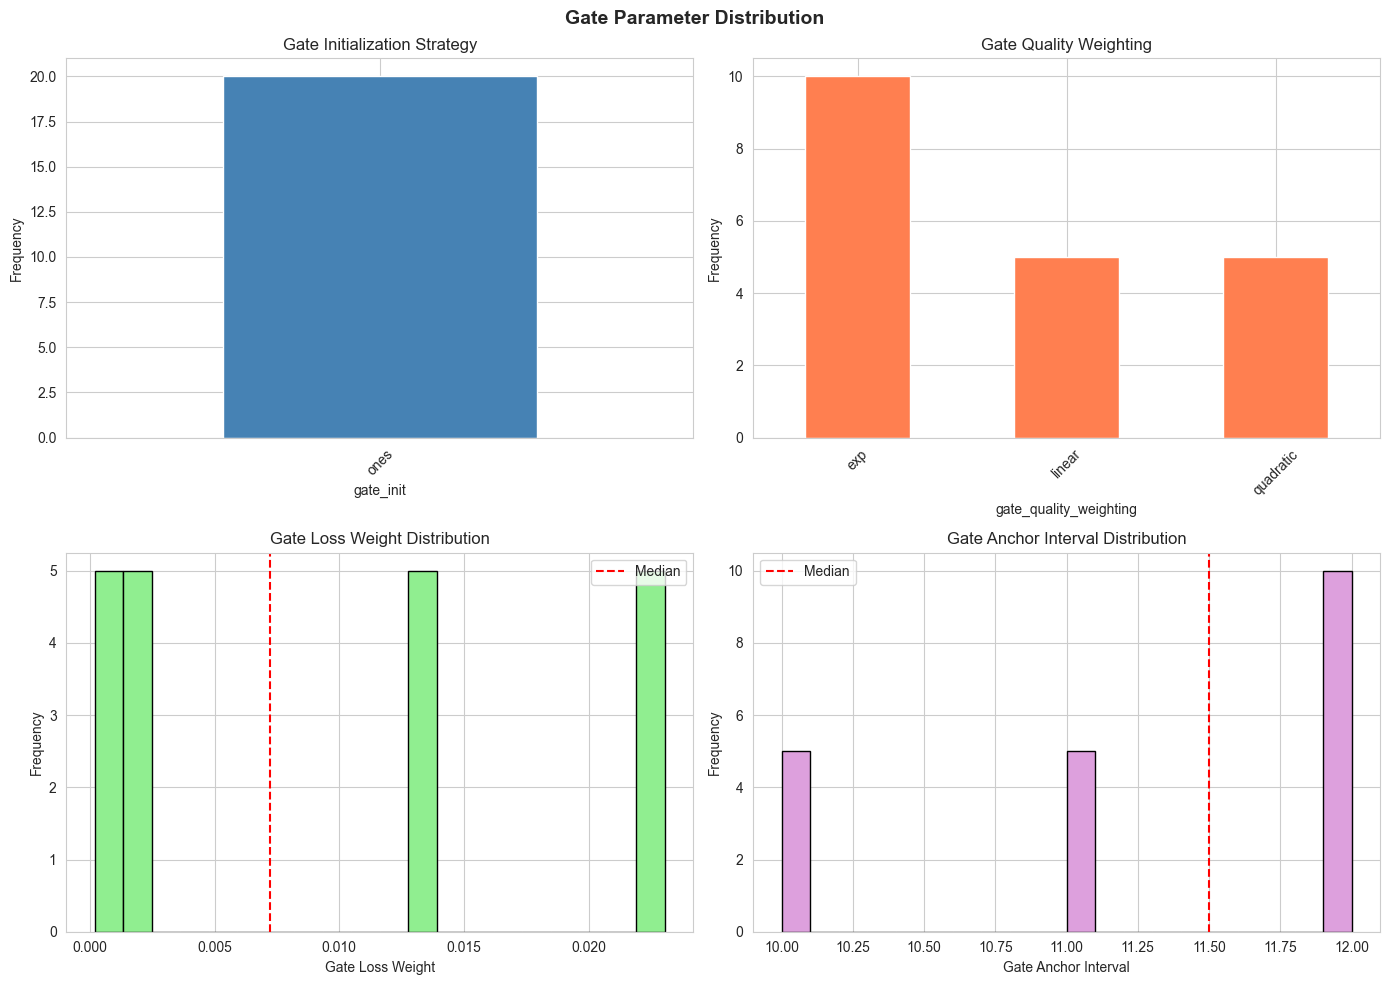

In [20]:
if len(gate_experiments) > 0:
    # Create visualizations for gate parameters
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Gate Parameter Distribution', fontsize=14, fontweight='bold')
    
    # Gate initialization
    if 'gate_init' in gate_experiments.columns:
        ax = axes[0, 0]
        gate_experiments['gate_init'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title('Gate Initialization Strategy')
        ax.set_ylabel('Frequency')
        ax.tick_params(axis='x', rotation=45)
    
    # Gate quality weighting
    if 'gate_quality_weighting' in gate_experiments.columns:
        ax = axes[0, 1]
        gate_experiments['gate_quality_weighting'].value_counts().plot(kind='bar', ax=ax, color='coral')
        ax.set_title('Gate Quality Weighting')
        ax.set_ylabel('Frequency')
        ax.tick_params(axis='x', rotation=45)
    
    # Gate loss weight distribution
    if 'gate_loss_weight' in gate_experiments.columns:
        ax = axes[1, 0]
        gate_experiments['gate_loss_weight'].hist(bins=20, ax=ax, color='lightgreen', edgecolor='black')
        ax.set_title('Gate Loss Weight Distribution')
        ax.set_xlabel('Gate Loss Weight')
        ax.set_ylabel('Frequency')
        ax.axvline(gate_experiments['gate_loss_weight'].median(), color='red', linestyle='--', label='Median')
        ax.legend()
    
    # Gate anchor interval distribution
    if 'gate_anchor_interval' in gate_experiments.columns:
        ax = axes[1, 1]
        gate_experiments['gate_anchor_interval'].hist(bins=20, ax=ax, color='plum', edgecolor='black')
        ax.set_title('Gate Anchor Interval Distribution')
        ax.set_xlabel('Gate Anchor Interval')
        ax.set_ylabel('Frequency')
        ax.axvline(gate_experiments['gate_anchor_interval'].median(), color='red', linestyle='--', label='Median')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

### 4.3 Correlation Between Gate Parameters and Performance

In [21]:
if len(gate_experiments) > 0:
    print("="*80)
    print("GATE PARAMETER IMPACT ON PERFORMANCE")
    print("="*80)
    
    # Separate by task type
    for task in ['classification', 'regression']:
        task_gates = gate_experiments[gate_experiments['task_type'] == task].copy()
        
        if len(task_gates) == 0:
            continue
        
        print(f"\n### {task.upper()} ###\n")
        
        metric = 'test_f1' if task == 'classification' else 'test_r2'
        
        # Analyze by categorical parameters
        for param in ['gate_init', 'gate_quality_weighting', 'gate_loss_scheduler']:
            if param in task_gates.columns:
                print(f"\nPerformance by {param}:")
                perf_by_param = task_gates.groupby(param)[metric].agg(['mean', 'std', 'count'])
                print(perf_by_param.to_string())
        
        # Correlation with numerical parameters
        print("\n\nCorrelation with numerical gate parameters:")
        numerical_gate_params = ['gate_loss_weight', 'gate_anchor_interval', 'final_gate_sparsity']
        available_params = [p for p in numerical_gate_params if p in task_gates.columns]
        
        if available_params:
            correlations = task_gates[available_params + [metric]].corr()[metric].drop(metric)
            print(correlations.to_string())

GATE PARAMETER IMPACT ON PERFORMANCE

### CLASSIFICATION ###


Performance by gate_init:
               mean       std  count
gate_init                           
ones       0.956131  0.014007     20

Performance by gate_quality_weighting:
                            mean       std  count
gate_quality_weighting                           
exp                     0.954431  0.014374     10
linear                  0.959054  0.006933      5
quadratic               0.956610  0.020022      5

Performance by gate_loss_scheduler:
                         mean       std  count
gate_loss_scheduler                           
cosine               0.955678  0.008784     10
decay                0.956584  0.018347     10


Correlation with numerical gate parameters:
gate_loss_weight        0.093619
gate_anchor_interval   -0.138504
final_gate_sparsity    -0.612092


## 5. Summary and Conclusions

In [22]:
print("="*80)
print("SUMMARY OF KEY FINDINGS")
print("="*80)

print("\n### 1. Performance Analysis ###\n")

# Classification summary
print("\nCLASSIFICATION TASKS:")
print("-" * 40)
for mode in ['clean', 'ar', 'nar']:
    mode_data = results_df[(results_df['data_mode'] == mode) & (results_df['task_type'] == 'classification')]
    if len(mode_data) > 0:
        avg_perf = mode_data.groupby('model_config')['test_f1'].mean().sort_values(ascending=False)
        print(f"\n{mode.upper()} data:")
        print(f"  Best: {avg_perf.index[0]} (F1={avg_perf.iloc[0]:.4f})")
        if 'MLP + Gate' in avg_perf.index and 'MLP' in avg_perf.index:
            improvement = ((avg_perf.loc['MLP + Gate'] - avg_perf.loc['MLP']) / avg_perf.loc['MLP']) * 100
            print(f"  Gate improvement: {improvement:+.2f}%")

# Regression summary
print("\n\nREGRESSION TASKS:")
print("-" * 40)
for mode in ['clean', 'ar', 'nar']:
    mode_data = results_df[(results_df['data_mode'] == mode) & (results_df['task_type'] == 'regression')]
    if len(mode_data) > 0:
        avg_perf = mode_data.groupby('model_config')['test_r2'].mean().sort_values(ascending=False)
        print(f"\n{mode.upper()} data:")
        print(f"  Best: {avg_perf.index[0]} (R2={avg_perf.iloc[0]:.4f})")
        if 'MLP + Gate' in avg_perf.index and 'MLP' in avg_perf.index:
            improvement = ((avg_perf.loc['MLP + Gate'] - avg_perf.loc['MLP']) / avg_perf.loc['MLP']) * 100
            print(f"  Gate improvement: {improvement:+.2f}%")

print("\n\n### 2. Convergence Speed ###\n")
print("Average epochs to reach 90% of final performance:")
conv_summary = results_df.groupby(['task_type', 'data_mode', 'model_config'])['epochs_to_90pct'].mean()
print(conv_summary.to_string())

print("\n\n### 3. Gate Configuration Preferences ###\n")
if len(gate_experiments) > 0:
    print("Most common gate configurations:")
    print(f"  - Initialization: {gate_experiments['gate_init'].mode()[0] if 'gate_init' in gate_experiments else 'N/A'}")
    print(f"  - Quality weighting: {gate_experiments['gate_quality_weighting'].mode()[0] if 'gate_quality_weighting' in gate_experiments else 'N/A'}")
    print(f"  - Loss scheduler: {gate_experiments['gate_loss_scheduler'].mode()[0] if 'gate_loss_scheduler' in gate_experiments else 'N/A'}")
    if 'gate_loss_weight' in gate_experiments.columns:
        print(f"  - Median loss weight: {gate_experiments['gate_loss_weight'].median():.4f}")
    if 'gate_anchor_interval' in gate_experiments.columns:
        print(f"  - Median anchor interval: {gate_experiments['gate_anchor_interval'].median():.1f}")

print("\n\n### 4. Overall Conclusion ###\n")
print("Gates as proximal mechanism for training MLPs:")
print("  - Examine the performance improvements above to determine effectiveness")
print("  - Check convergence speed to see if gates accelerate learning")
print("  - Review gate parameter preferences to understand optimal configurations")

SUMMARY OF KEY FINDINGS

### 1. Performance Analysis ###


CLASSIFICATION TASKS:
----------------------------------------

CLEAN data:
  Best: Linear (F1=0.9564)

AR data:
  Best: MLP + Curr (F1=0.9591)
  Gate improvement: +0.45%

NAR data:
  Best: MLP (F1=0.9566)
  Gate improvement: +0.00%


REGRESSION TASKS:
----------------------------------------


### 2. Convergence Speed ###

Average epochs to reach 90% of final performance:
task_type       data_mode  model_config     
classification  ar         Linear               1.0
                           MLP                  0.8
                           MLP + Curr           1.2
                           MLP + Curr + Gate    0.8
                           MLP + Gate           1.0
                clean      Linear               1.2
                           MLP                  1.2
                nar        Linear               0.6
                           MLP                  3.8
                           MLP + Curr           4.6
